Dataset Matrix: 20631 samples, 32 features, 100 engine units.

--- Model Cross-Validation Performance ---
           Model  CV RMSE (Mean)  CV MAE (Mean)  C-MAPSS Score (Total)
         XGBoost       18.151400      13.275629          273393.461070
        LightGBM       18.176646      13.225738          276631.763207
Ridge Regression       21.405047      17.564372          181815.878882


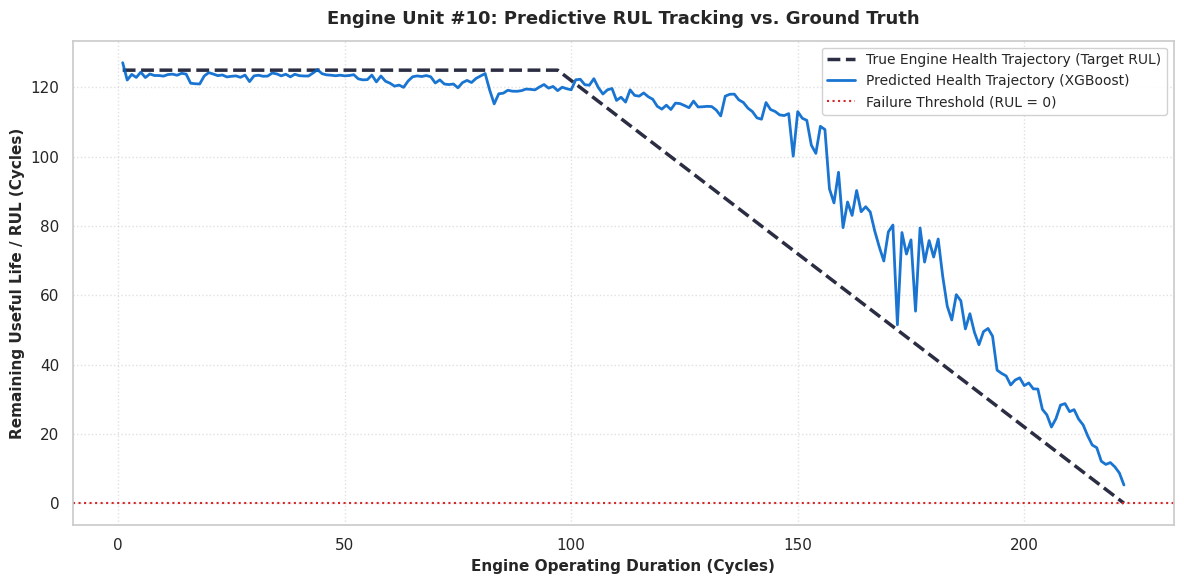

/var/folders/h4/34l5wj_13dgg7yf7fpzdm4f80000gn/T/ipykernel_60006/2096829377.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


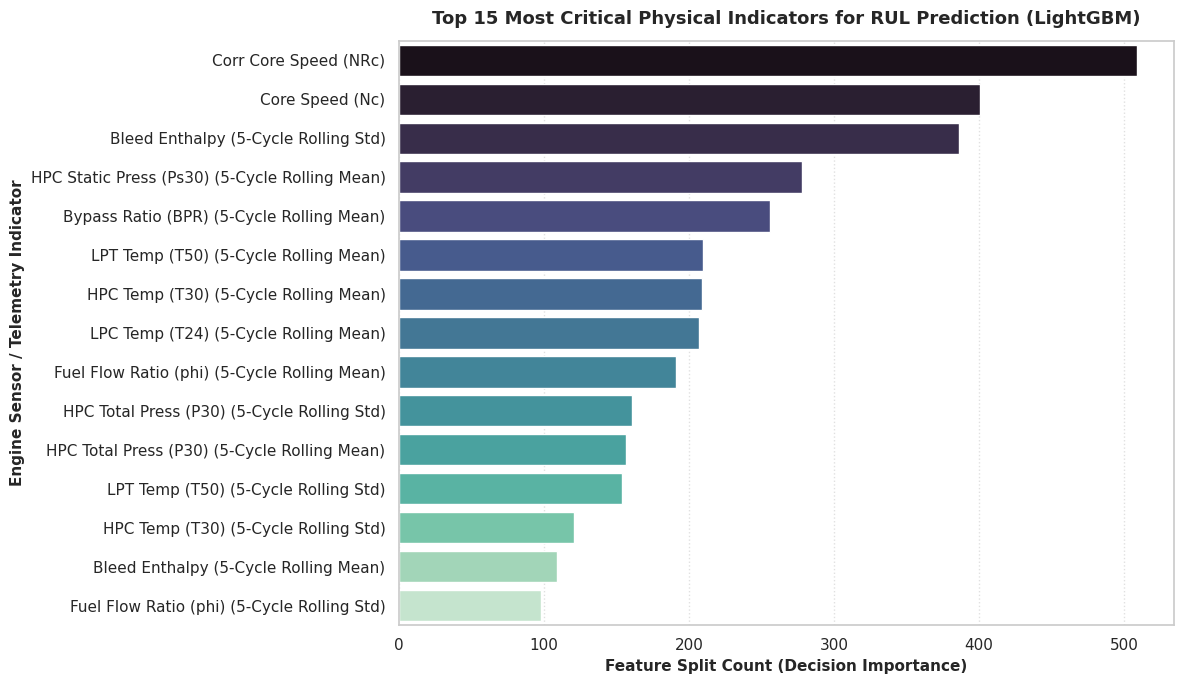

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
import xgboost as xgb

# Global Plot Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.family": "sans-serif"})

# Base Directory Setup
BASE_DIR = "***/data_analysis_portfolio/project-2"
DATA_PATH = os.path.join(BASE_DIR, "data/processed/cmapss_engineered.csv")
FIGURES_DIR = os.path.join(BASE_DIR, "reports/figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

# 1. Load Engineered Dataset
df = pd.read_csv(DATA_PATH)

# Drop collinear/constant features identified during VIF analysis
cols_to_drop = ["setting_3"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Asymmetric C-MAPSS Scoring Function
def cmapss_score(y_true, y_pred):
    """Calculates the official asymmetric NASA C-MAPSS evaluation metric.
    Penalizes late predictions (y_pred > y_true) significantly higher than early ones.
    """
    d = y_pred - y_true
    score = np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0))
    return score

# 3. Piece-wise RUL Target Clipping (Standard C-MAPSS Pre-processing)
# RUL is capped at 125 cycles as healthy engines show negligible degradation early on
RUL_CAP = 125
df["RUL_clipped"] = df["RUL"].clip(upper=RUL_CAP)

# 4. Train/Test Feature Matrix Setup
meta_cols = ["unit_nr", "time_cycles", "RUL", "RUL_clipped"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = df["RUL_clipped"].values
groups = df["unit_nr"].values

print(f"Dataset Matrix: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(groups))} engine units.")

# 5. GroupKFold Cross-Validation Setup
gkf = GroupKFold(n_splits=5)

models = {
    "Ridge Regression": Ridge(alpha=100.0),
    "LightGBM": LGBMRegressor(
        n_estimators=150,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=5,
        random_state=42,
        verbosity=0
    )
}

results = []
oof_predictions = {name: np.zeros(len(df)) for name in models.keys()}

# Cross-Validation Loop
for model_name, model in models.items():
    rmse_list, mae_list, score_list = [], [], []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        oof_predictions[model_name][val_idx] = preds

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        mae = mean_absolute_error(y_val, preds)
        score = cmapss_score(y_val, preds)

        rmse_list.append(rmse)
        mae_list.append(mae)
        score_list.append(score)

    results.append({
        "Model": model_name,
        "CV RMSE (Mean)": np.mean(rmse_list),
        "CV MAE (Mean)": np.mean(mae_list),
        "C-MAPSS Score (Total)": np.sum(score_list)
    })

results_df = pd.DataFrame(results).sort_values(by="CV RMSE (Mean)")
print("\n--- Model Cross-Validation Performance ---")
print(results_df.to_string(index=False))

# 6. Plot Predicted vs Actual RUL Trajectory (Enhanced)
best_model_name = results_df.iloc[0]["Model"]
df["preds"] = oof_predictions[best_model_name]

sample_unit = 10
sample_engine_df = df[df["unit_nr"] == sample_unit].sort_values(by="time_cycles")

plt.figure(figsize=(12, 6))

# Target Line
plt.plot(
    sample_engine_df["time_cycles"],
    sample_engine_df["RUL_clipped"],
    label="True Engine Health Trajectory (Target RUL)",
    color="#2B2D42",
    linewidth=2.5,
    linestyle="--",
)

# Model Prediction Line
plt.plot(
    sample_engine_df["time_cycles"],
    sample_engine_df["preds"],
    label=f"Predicted Health Trajectory ({best_model_name})",
    color="#0066CC",
    linewidth=2,
    alpha=0.9,
)

# Visual Threshold Annotation
plt.axhline(y=0, color="#D62728", linestyle=":", linewidth=1.5, label="Failure Threshold (RUL = 0)")

plt.title(
    f"Engine Unit #{sample_unit}: Predictive RUL Tracking vs. Ground Truth",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Engine Operating Duration (Cycles)", fontsize=11, fontweight="bold")
plt.ylabel("Remaining Useful Life / RUL (Cycles)", fontsize=11, fontweight="bold")

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9, fontsize=10)
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "rul_prediction_trajectory.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# 7. Feature Importance Analysis with Physical Mapping
readable_labels_map = {
    "setting_1": "Altitude (Setting 1)",
    "setting_2": "Mach Number (Setting 2)",
    "s_2": "LPC Temp (T24)",
    "s_3": "HPC Temp (T30)",
    "s_4": "LPT Temp (T50)",
    "s_7": "HPC Total Press (P30)",
    "s_8": "Fan Speed (Nf)",
    "s_9": "Core Speed (Nc)",
    "s_11": "HPC Static Press (Ps30)",
    "s_12": "Fuel Flow Ratio (phi)",
    "s_13": "Corr Fan Speed (NRf)",
    "s_14": "Corr Core Speed (NRc)",
    "s_15": "Bypass Ratio (BPR)",
    "s_17": "Bleed Enthalpy",
    "s_20": "HPT Bleed",
    "s_21": "LPT Bleed",
}

def format_feature_name(feat_name):
    """Converts raw sensor IDs into human-readable physical telemetry labels."""
    is_roll_mean = "_roll_mean" in feat_name
    is_roll_std = "_roll_std" in feat_name
    
    base_feat = feat_name.replace("_roll_mean", "").replace("_roll_std", "")
    label = readable_labels_map.get(base_feat, base_feat)
    
    if is_roll_mean:
        return f"{label} (5-Cycle Rolling Mean)"
    elif is_roll_std:
        return f"{label} (5-Cycle Rolling Std)"
    return label

# Train best tree-based model for importances
best_tree_model = models["LightGBM"]
best_tree_model.fit(X, y)

importance_df = pd.DataFrame({
    "Raw_Feature": feature_cols,
    "Importance": best_tree_model.feature_importances_,
})

importance_df["Feature"] = importance_df["Raw_Feature"].apply(format_feature_name)
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="mako",
)

plt.title(
    "Top 15 Most Critical Physical Indicators for RUL Prediction (LightGBM)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Feature Split Count (Decision Importance)", fontsize=11, fontweight="bold")
plt.ylabel("Engine Sensor / Telemetry Indicator", fontsize=11, fontweight="bold")
plt.grid(True, axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "feature_importance.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()